In [52]:
import os,sys,copy
import torchvision
import argparse
import torch
import tqdm

os.environ["CUDA_VISIBLE_DEVICES"]='3'

import src.misc.dist as dist 
from src.core import YAMLConfig 
from src.solver import TASKS
from src.data import get_coco_api_from_dataset

from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral
from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text
import draw_box_utils
import PIL
from PIL import ImageColor, Image
import PIL.ImageDraw as ImageDraw
import numpy as np
import src
from rdkit.Chem import Draw, AllChem
import pandas as pd
import rdkit
from rdkit import Chem


os.environ["CUDA_VISIBLE_DEVICES"]='1'
sys.path.append("/home/jovyan/rt-detr/rt-detr")
from src.solver.utils import output_to_smiles
os.chdir('/home/jovyan/rt-detr/rt-detr')
os.getcwd()
# conda install -n ocr   conda-forge::libgl   for import cv2 succus

# "jupyter nbconvert  real_testing.ipynb  --to script"

'/home/jovyan/rt-detr/rt-detr'

In [53]:
import pandas as pd
from rdkit import Chem

# 假设你已经有一个DataFrame df
# df = pd.read_csv('your_file.csv')  # 例如从CSV文件读取数据
# 定义一个函数来生成标准的RDKit SMILES
def standardize_smiles(smiles):
    try:
        # 将SMILES字符串转换为RDKit的Mol对象
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            # 生成标准的SMILES
            standardized_smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
            return standardized_smiles
        else:
            return None  # 如果SMILES无效，返回None
    except:
        return None  # 如果出现异常，返回None



In [54]:
real_datadir='/home/jovyan/rt-detr/data'
dname='acs'
# ddir=f"{real_datadir}/"
dfile=f"{real_datadir}/{dname}.csv"
ddf=pd.read_csv(dfile)


In [55]:
# 应用函数到SMILES列
ddf['standard_SMILES'] = ddf['SMILES'].apply(standardize_smiles)
# 查看结果
print(ddf.head(2))

  image_id       file_path                                             SMILES  \
0        1  real/acs/1.png                                 O=C(N1S[R'])CCC1=O   
1        2  real/acs/2.png  COC(C=C1)=CC=C1C#CC(C=CC=C2)=C2C3=C(C=O)N4C=CC...   

                                     standard_SMILES  
0                                               None  
1  CCOC(=O)c1c(-c2ccccc2C#Cc2ccc(OC)cc2)c(C=O)n2c...  


In [67]:
from PIL import Image
import torch
from torchvision import transforms
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as F

def image_to_tensor(image_path):
    # Open the image using PIL
    image = Image.open(image_path)
    w, h = image.size
    # print("width: {}, height: {}".format(w, h))
    # Define a transform to convert the image to a tensor and normalize it
    transform = transforms.Compose([
        # transforms.Grayscale(num_output_channels=1),  # Convert to grayscale (1 channel)
        T.Resize((640, 640)),  # Resize the image to 224x224
        T.ToImageTensor(),  # Convert to Tensor (C x H x W)
        T.ConvertDtype(dtype=torch.float32)
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Optional normalization for pretrained models
    ])
    
    # Apply the transform to the image
    tensor = transform(image)
    
    return tensor,w,h

def show_atom_number(mol, label='molAtomMapNumber'):
    for atom in mol.GetAtoms():
        atom.SetProp(label, str(atom.GetIdx()))
    return mol
    
def remove_atom_number(mol, label='molAtomMapNumber'):
    # After performing the desired operation (e.g., showing), you can remove the property
    for atom in mol.GetAtoms():
        atom.ClearProp(label)  # Removes the atom index property
    return mol

# After performing the desired operation (e.g., showing), you can remove the property
    for atom in mol.GetAtoms():
        atom.ClearProp(label)  # Removes the atom index property

def remove_SP(input_string):
    # if "S@SP1" in input_string:
    #     input_string = input_string.replace("S@SP1", "S")
    # elif "S@SP2" in input_string:
    #     input_string = input_string.replace("S@SP2", "S")
    # elif "S@SP3" in input_string:
    #     input_string = input_string.replace("S@SP3", "S")
    input_string = re.sub(r'@SP[1-3]', '', input_string)
    return input_string

import pandas as pd
import math
from scipy.spatial import cKDTree


def assemble_atoms_with_charges(atom_list, charge_list):
    used_charge_indices=set()
    kdt = cKDTree(atom_list[['x','y']])
    for i, charge in charge_list.iterrows():
        if i in used_charge_indices:
            continue
        charge_=charge['charge']
        if charge_=='1':charge_='+'
        dist, idx_atom=kdt.query([charge_list.x[i],charge_list.y[i]], k=1)
        atom_str=atom_list.loc[idx_atom,'atom'] 
        atom_ = re.findall(r'[A-Za-z]+', atom_str)[0] + charge_
        atom_list.loc[idx_atom,'atom']=atom_

    return atom_list
    


import re
pattern =  "(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"
regex = re.compile(pattern)

def atomwise_tokenizer(smi, regex=regex,exclusive_tokens = None):
    """
    Tokenize a SMILES molecule at atom-level:
        (1) 'Br' and 'Cl' are two-character tokens
        (2) Symbols with bracket are considered as tokens

    exclusive_tokens: A list of specifical symbols with bracket you want to keep. e.g., ['[C@@H]', '[nH]'].
    Other symbols with bracket will be replaced by '[UNK]'. default is `None`.
    """
    tokens = [token for token in regex.findall(smi)]
    if exclusive_tokens:
        for i, tok in enumerate(tokens):
            if tok.startswith('['):
                if tok not in exclusive_tokens:
                    tokens[i] = '[UNK]'
    return tokens

bond_labels = [13,14,15,16,17]
# idx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
#             9:'I',10:'P',11:'*',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
#             16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'+2',} #NONE is single ?
idx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
            9:'I',10:'P',11:'H',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
            16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'2',
            23:'CF3',
            24:'CN',
            25:'Me',
            26:'CO2Et',
            27:'R',
            28:'Ph',
            29:'*',
            # 30:'MeO',
            # 31:'*',
            # 32:'*',
            } #NONE is single ?

In [68]:
home="/home/jovyan/rt-detr"
pt_outhome='/home/jovyan/volume/samba_share/from_docker/ocr_data/rtdetr_output'
pp="tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/best_checkpoint.pth"
cc="tools/output/rtdetr_r50vd_6x_coco_real_resample_adapter_both/checkpoint0068.pth"
tt="./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpter2/best_checkpoint.pth"
diffS='./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpterWithoutJPO_diffSize/checkpoint0071.pth'
# tr1='blured_merged_diff300start11'
# tr1='blured_merged_diff300start12'
# tr1='blured_merged_diff300start12_hand'
tr1='blured_merged_diff300start12_hand_addedObstac'
tr1='merged9'
# diffS="/home/jovyan/volume/samba_share/from_docker/ocr_data/rtdetr_output/merged9/best_checkpoint.pth"

parser = argparse.ArgumentParser()
parser.add_argument('--config', '-c', type=str, default=f'{home}/rt-detr/configs/rtdetr/rtdetr_r50vd_6x_coco.yml')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{diffS}')
parser.add_argument('--resume', '-r', type=str, default=f'{pt_outhome}/{tr1}/best_checkpoint.pth')

parser.add_argument('--tuning', '-t', type=str,)# default='/home/jovyan/model_checkpoint/rtdetr_r50vd_2x_coco_objects365_from_paddle.pth')
parser.add_argument('--test-only',default=True,)
parser.add_argument('--amp', default=False,)

args, unknown = parser.parse_known_args()#in jupyter

In [69]:
cfg = YAMLConfig(
        args.config,
        resume=args.resume, 
        use_amp=args.amp,
        tuning=args.tuning
    )
args.gpu_device=0
cfg.device=torch.device('cuda', args.gpu_device) if torch.cuda.is_available() else torch.device('cpu') 

In [59]:
_model=cfg.model
#postprocess need the image original size
if torch.cuda.is_available():
    saved_statDict=torch.load(cfg.resume)
else:
    saved_statDict=torch.load(cfg.resume,map_location=torch.device('cpu'))
loaded_state_dict=saved_statDict['model']
#comaparing with pretrained_model
current_model_dict=_model.state_dict()

postprocessor = cfg.postprocessor##RTDETRPostProcessor@@src/zoo/rtertr

Load PResNet50 state_dict


In [70]:
from src.zoo.rtdetr.rtdetr_postprocessor import RTDETRPostProcessor
postprocessor2=RTDETRPostProcessor(num_classes=30, use_focal_loss=True, num_top_queries=300, remap_mscoco_category=False)

In [1]:
import pandas as pd


In [4]:
csv_path="/home/jovyan/rt-detr/rt-detr/hand_output.csv"
df = pd.read_csv(csv_path)
df.head()

,img_path,smiles,smiles_pred
0,/home/jovyan/volume/samba_share/from_docker/oc...,C\1=C/C(=N\Br)/C(=C/C1=N/Br)Cl,ClC1=C/C(=N/Br)C=C/C1=N\Br
1,/home/jovyan/volume/samba_share/from_docker/oc...,C1C[C@H]([C@@H](C1)O)CCCO,OCCC[C@@H]1CCC[C@H]1O
2,/home/jovyan/volume/samba_share/from_docker/oc...,CCSN1CCN(CC1)SCC,CCSN1CCN(SCC)CC1
3,/home/jovyan/volume/samba_share/from_docker/oc...,CN(C)C1=CC1=NC#N,CN(C)c1c/c1=N\C#N
4,/home/jovyan/volume/samba_share/from_docker/oc...,CC(=C[C@@H]1[C@@H](C1(C)C)C(=O)O)C,CC(C)=C[C@@H]1[C@H](C(=O)O)C1(C)C


In [7]:
i=0
png_filename = df.img_path[0]
png_filename,df.smiles[0]

('/home/jovyan/volume/samba_share/from_docker/ocr_data/handDrawLike/DECIMER_HDM/images/train/CDK_Depict_1_2.png',
 'C\\1=C/C(=N\\Br)/C(=C/C1=N/Br)Cl')

In [71]:
#loaidng trained weights

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

#NOTE make sure current_model_dict contating all the loaded_state_dict
key_ori=loaded_state_dict.keys()
key_cur=current_model_dict.keys()
diff_cur=[k for k in key_cur  if k not in key_ori]
diff_ori=[k for k in key_ori if k not in key_cur]#loaded is the original as pretrained
#hehre we only considering new model >= pretrained, not the other case here
same_=[k for k in key_cur if k in key_ori]
# assert len(diff_ori)==0, 
print(f'make sure loaded pretrained model keys: {len(key_ori)} are all included in current build model keys: {len(key_cur)}\n In futhre we considering only part intersection!!')
new_state_dict=dict()
i=0;j=0
for k in same_:
    if loaded_state_dict[k].size()==current_model_dict[k].size():
        new_state_dict[k]=loaded_state_dict[k]
        # print(f'current{k},{current_model_dict[k].size()},ori{loaded_state_dict[k].size()}')
        i+=1
    else:
        new_state_dict[k]=current_model_dict[k] #confg such image_size diff lead
        j+=1
_model.load_state_dict(new_state_dict, strict=False)
print(f'{bcolors.WARNING}have partly load the match paramters>>number of:{len(new_state_dict.keys())}@finalLoad, all:{len(current_model_dict.keys())}@buildModel, {len(loaded_state_dict.keys())}@pretrained. {bcolors.ENDC}')
print(f' {bcolors.WARNING} loaded keys {i}, skip mismatch size keys {j} (same nnName but diff dimensions)')


make sure loaded pretrained model keys: 808 are all included in current build model keys: 808
 In futhre we considering only part intersection!!
have partly load the match paramters>>number of:808@finalLoad, all:808@buildModel, 808@pretrained. 
  loaded keys 808, skip mismatch size keys 0 (same nnName but diff dimensions)


In [72]:
# smi='[*1]C1(O[Ru]C1([Ar])[*2])[*3]'
# mol=Chem.MolFromSmiles(smi)

In [73]:
ddf.head(2)

,image_id,file_path,SMILES,standard_SMILES
0,1,real/acs/1.png,O=C(N1S[R'])CCC1=O,None
1,2,real/acs/2.png,COC(C=C1)=CC=C1C#CC(C=CC=C2)=C2C3=C(C=O)N4C=CC...,CCOC(=O)c1c(-c2ccccc2C#Cc2ccc(OC)cc2)c(C=O)n2c...


In [74]:
real_datadir

'/home/jovyan/rt-detr/data'

In [75]:
# 计算 IoU（交并比）
def calculate_iou(box1, box2):
    """
    计算两个框的 IoU。
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # 计算交集面积
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    # 计算并集面积
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    # 计算 IoU
    iou = inter_area / union_area if union_area > 0 else 0
    return iou


In [76]:
_model.eval()
output_dir="/home/jovyan/rt-detr/data/real_results"
os.makedirs(f'{output_dir}/real/acs', exist_ok=True)

Rebuilt_SMI=[]

#check & saving
visual_check=True
other2ppsocr=False
opts = Draw.MolDrawOptions()
opts.addAtomIndices = False
opts.addStereoAnnotation = False

with torch.no_grad():
    for idrow,fpth in  enumerate(ddf.file_path):
        # print(fpth)
        # idrow=0
        image_path=f"{real_datadir}/{ ddf.file_path[idrow]}"
        img_ori = Image.open(image_path).convert('RGB')
        w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
        # Example usage: #change thie image
        tensor,w,h = image_to_tensor(image_path)
        tensor=tensor.unsqueeze(0)
        # print(tensor.size())  # Output tensor shape (C x H x W)
        outputs = _model(tensor)
        ori_size=torch.Tensor([w,h]).long().unsqueeze(0)
        # result_ = postprocessor(outputs, ori_size)
        result_ = postprocessor2(outputs, ori_size)

        # result_ = postprocessor(out_, torch.Tensor([w,h]))
        score_=result_[0]['scores']
        boxe_=result_[0]['boxes']
        label_=result_[0]['labels']
        selected_indices =score_ > 0.5
        # selected_indices =score_ > score_.mean()
        # 统计 True 的数量
        true_count = selected_indices.sum().item()
        try:
            output={
                'labels': label_[selected_indices],
                'boxes': boxe_[selected_indices],
                'scores': score_[selected_indices]
            }
            filtered_output_dict={image_path: output
            }
            x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
            y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
            center_coords = torch.stack((x_center, y_center), dim=1)
            output = {'bbox':         output["boxes"].to("cpu").numpy(),
                        'bbox_centers': center_coords.to("cpu").numpy(),
                        'scores':       output["scores"].to("cpu").numpy(),
                        'pred_classes': output["labels"].to("cpu").numpy()}
            #visual checking
            predict_boxes = output['bbox']
            predict_classes = output['pred_classes']
            predict_scores = output['scores']

            img_ori = Image.open(image_path).convert('RGB')
            w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
            # print(w_ori, h_ori, "orignianl vs 1000,1000")
            # 计算缩放比例
            scale_x = 1000 / w_ori
            scale_y = 1000 / h_ori
            img_ori_1k = img_ori.resize((1000,1000))
            img = Image.open(image_path).convert('RGB')
            img = img.resize((1000,1000))
            newbox = predict_boxes * [scale_x, scale_y, scale_x, scale_y]
            boxed_img = draw_objs(img,
                                    newbox,
                                    predict_classes,
                                    predict_scores,
                                    category_index=idx_to_labels,
                                    box_thresh=0.5,
                                    line_thickness=3,
                                    font='arial.ttf',
                                    font_size=10)
            atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                                bond_labels=bond_labels,  result=[])
            smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit
        except Exception as e:
            print(fpth)
            print(f"selected_indices 中 True 的数量: {true_count}")
            smiles=None
            print(e)

        Rebuilt_SMI.append(smiles)
        
        # TODO #[3H] 2H prpared box for training are too smalled, need adjust
        if visual_check:
            img_ori = Image.open(image_path).convert('RGB')
            img_ori_1k = img_ori.resize((1000,1000))
            if other2ppsocr:
                img_rebuit = Draw.MolToImage(final_mol, options=opts,size=(1000, 1000))
            else:
                img_rebuit = Draw.MolToImage(mol_rebuit, options=opts,size=(1000, 1000))
            combined_img = Image.new('RGB', (img_ori_1k.width + boxed_img.width + img_rebuit.width, img_ori_1k.height))
            combined_img.paste(img_ori_1k, (0, 0))
            combined_img.paste(boxed_img, (img_ori_1k.width, 0))
            combined_img.paste(img_rebuit, (img_ori_1k.width + boxed_img.width, 0))
            combined_img.save(f"{output_dir}/{fpth}")
        
        # if idrow==4:break


ddf['I2SMILES']=Rebuilt_SMI
equal_count = (ddf['standard_SMILES'] == ddf['I2SMILES']).sum()
print(f"Rdkit standard and rebuilt right numb : {equal_count}")

捕获到   异常@@Post-condition Violation
	Element 'Ph' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2024.03.5
	BOOST: 1_84

Error@@node Ph0 atom@@ Ph 

['O0', 'C0', 'C0', 'O0', 'Ph0', 'C0', 'C0'] idx:4,atoms[idx]::Ph0
real/acs/1.png
selected_indices 中 True 的数量: 13
cannot unpack non-iterable NoneType object
捕获到   异常@@Post-condition Violation
	Element 'CO2Et' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2024.03.5
	BOOST: 1_84

Error@@node CO2Et0 atom@@ CO2Et 

['C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', 'C0', '*0', 'C0', 'CO2Et0', 'C0', 'N0', 'O0'] idx:23,atoms[idx]::CO2Et0
real/acs/2.png
selected_indices 中 True 的数量: 59
cannot unpack non-iterable NoneType object
捕获到   异常@@Post-condition Violation
	Element 'R' not found
	Violation occurred on line 93 in file Code/GraphMol/Perio

In [77]:
ddf['I2SMILES']=Rebuilt_SMI
equal_count = (ddf['standard_SMILES'] == ddf['I2SMILES']).sum()
print(f"Rdkit standard and rebuilt right numb : {equal_count}")

Rdkit standard and rebuilt right numb : 27


In [51]:
#TODO  adding OCR after training with extended labels

In [143]:
node_index = (predict_classes >= 0) & (predict_classes <= 12) #TODO chanrge 
node_scores = predict_scores[node_index]
node_boxes = predict_boxes[node_index]
node_labels = predict_classes[node_index] #todo go on hits


In [144]:
i=0
for la, s, box in zip(node_labels,node_scores,node_boxes):
    print(la, s, box )
    i+=1
print(i)    

1 0.9176356 [359.9018  138.91437 417.9999  198.68546]
1 0.9110899 [444.94244 754.0718  502.35736 813.6834 ]
1 0.9092437 [223.62978 182.76971 281.19565 243.75787]
1 0.9091138 [588.8554  256.05554 645.9077  315.65   ]
1 0.90740174 [359.93048 370.96237 416.77252 431.7242 ]
1 0.9073093 [443.914   255.57095 502.88785 316.30148]
1 0.906758 [ 300.2116  1005.3143   358.81955 1065.193  ]
1 0.9066524 [ 445.0722  1006.11646  501.65833 1065.1337 ]
1 0.9057782 [404.23712 509.38477 462.76605 568.84686]
2 0.90284574 [282.79733 596.91907 369.04193 684.19476]
1 0.902669 [660.8315  129.14594 718.3674  190.20155]
1 0.9010238 [804.9761  381.56134 862.3746  440.75592]
1 0.9006574 [516.177  880.4435 574.6131 939.2471]
1 0.89993286 [661.02325 382.01062 718.34906 441.0078 ]
1 0.89852625 [ 98.356674 110.56042  156.68736  171.32916 ]
1 0.8974504 [805.05536 129.60364 862.77527 189.77678]
1 0.8962214 [ 99.33806 399.91306 155.55183 460.0122 ]
1 0.8925085 [300.13092 753.40393 358.00992 814.8395 ]
1 0.8903719 [589.8

In [ ]:
ddf['I2SMILES']=Rebuilt_SMI
equal_count = (ddf['standard_SMILES'] == ddf['I2SMILES']).sum()
print(f"Rdkit standard and rebuilt right numb : {equal_count}")

In [48]:
ddf.head()

,image_id,file_path,SMILES,standard_SMILES,I2SMILES
0,1,real/acs/1.png,O=C(N1S[R'])CCC1=O,None,*N1C(=O)CCC1=O
1,2,real/acs/2.png,COC(C=C1)=CC=C1C#CC(C=CC=C2)=C2C3=C(C=O)N4C=CC...,CCOC(=O)c1c(-c2ccccc2C#Cc2ccc(OC)cc2)c(C=O)n2c...,*c1c(-c2ccccc2C#Cc2ccccc2)c(C=O)n2ccccc12.C
2,3,real/acs/3.png,O=C(N[R])CCC(N[R])=O,None,B.BNC(=O)CCC(N)=O
3,4,real/acs/4.png,ClC(CCC(Cl)=O)=O,O=C(Cl)CCC(=O)Cl,O=C(Cl)CCC(=O)Cl
4,5,real/acs/5.png,CC1=CC([R2])=C([R2])[P-]1,None,C=C/C=C\F


In [49]:
equal_count = (ddf['standard_SMILES'] == ddf['I2SMILES']).sum()
print(f"Rdkit standard and rebuilt right numb : {equal_count}")

Rdkit standard and rebuilt right numb : 31


In [ ]:
#super group retraining

In [50]:
import  random

#rdkitbased img

def rdkit_addGroup(mol_sm="NCCC(CCO)CCBr",cyano_sm="C#N"):
    mol = Chem.MolFromSmiles(mol_sm)
    atoms_A = mol.GetNumAtoms()
    # Create a cyano group molecule
    cyano = Chem.MolFromSmiles(cyano_sm)
    atoms_site=[]
    for atom in mol.GetAtoms():
        atom_idx = atom.GetIdx()  # Get the atom index
        num_hydrogens = atom.GetTotalNumHs()  # Count hydrogens (including implicit)
        if num_hydrogens >0:
            atoms_site.append(atom_idx)
    # h_atom_indexA=6
    h_atom_indexA=random.choice(atoms_site)
    combined_mol = Chem.CombineMols(mol, cyano)
    rw_combined = Chem.RWMol(combined_mol)
    merged_atom_id=[]
    for i,atom in enumerate(rw_combined.GetAtoms()):
        if i >=atoms_A:
            num_hydrogens = atom.GetTotalNumHs()  # Count hydrogens (including implicit)
            if num_hydrogens >0:
                merged_atom_id.append(i)
    h_atom_indexB= random.choice(merged_atom_id)
    rw_combined.AddBond(h_atom_indexA,h_atom_indexB, Chem.rdchem.BondType.SINGLE)  # Triple bond to CN
    # reset radical electrons
    bonding_atoms=[h_atom_indexA,h_atom_indexB]
     # Convert all implicit hydrogens to explicit
    mol_with_h = Chem.AddHs(rw_combined,explicitOnly=True)#NOTE this avoid the N valence errors,n AddH node to convert implicit Hs to H atom here
    # Chem.RemoveHs(rw_mol)#only work for H atom
    rw_mol = Chem.RWMol(mol_with_h)
    for atom in reversed(mol_with_h.GetAtoms()):
        #H atom neigbor only one normaly
        if atom.GetSymbol() == 'H' and atom.GetNeighbors()[0].GetIdx() in bonding_atoms:#remove bond after H
            rw_mol.RemoveAtom(atom.GetIdx())
            bonding_atoms.remove(atom.GetNeighbors()[0].GetIdx())

    Chem.SanitizeMol(rw_mol)
    return rw_mol

In [ ]:
abrevie={23:'CF3',
                              24:'CN',
                              25:'Me',
                              26:'CO2Et',
                              27:'R',
                              28:'Ph',
                              }

In [35]:
from xml.dom import minidom
import random
import string


# dx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
#             9:'I',10:'P',11:'H',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
#             16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'2',} #NONE is single ?
dx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
                9:'I',10:'P',11:'H',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
                16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'2',
                23:'CF3',
                24:'CN',
                25:'Me',
                26:'CO2Et',
                27:'R',
                28:'Ph',
                29:'3~7UP'
                } #NONE is single ?
# ABBREVIATIONS 
abrevie={"[23*]":'CF3',
                              "[24*]":'CN',
                              "[25*]":'Me',
                              "[26*]":'CO2Et',
                              "[27*]":'R',
                              "[28*]":'Ph',
                            "[29*]":'3~7UP',
                            # "[30*]":'3~7low',
                            # "[31*]":'3~7UPlow',
                            # "[32*]":'3~7UPlownumber',
                              }#TODO add more common abreve
#https://github.com/thomas0809/MolScribe/blob/7296a30413eb55436702011efdff78131f66d162/molscribe/constants.py#L6


mol_sm="NCCC(CCO)CC"
# cyano_sm="[23*]"
# selected_group=random.choice(abrevie)
cyano_sm, selected_group = random.choice(list(abrevie.items()))

In [36]:
def abbRdkit2svg(mol_sm,cyano_sm, selected_group, writeSVG=True):
    mol = Chem.MolFromSmiles(mol_sm)
    atoms_A = mol.GetNumAtoms()
    # Create a cyano group molecule
    cyano = Chem.MolFromSmiles(cyano_sm)
    atoms_site=[]
    for atom in mol.GetAtoms():
        atom_idx = atom.GetIdx()  # Get the atom index
        num_hydrogens = atom.GetTotalNumHs()  # Count hydrogens (including implicit)
        if num_hydrogens >0:
            atoms_site.append(atom_idx)
    # h_atom_indexA=6
    h_atom_indexA=random.choice(atoms_site)
    combined_mol = Chem.CombineMols(mol, cyano)
    rw_combined = Chem.RWMol(combined_mol)
    merged_atom_id=[atoms_A]
    if cyano_sm=="[29*]":
        length = random.randint(3, 8)  # 随机长度
        selected_group = ''.join(random.choices(string.ascii_uppercase, k=length))
    # elif cyano_sm=="[30*]":
    #     length = random.randint(3, 8)  # 随机长度
    #     selected_group = ''.join(random.choices(string.ascii_lowercase, k=length))   
    elif cyano_sm=="[31*]":
        length = random.randint(3, 8)  # 随机长度
        selected_group = ''.join(random.choices(string.ascii_letters, k=length)) 
    elif cyano_sm=="[32*]":
        length = random.randint(3, 8)  # 随机长度
        selected_group = ''.join(random.choices(string.ascii_letters + string.digits, k=length)) 
    rw_combined.GetAtomWithIdx(atoms_A).SetProp("atomLabel", selected_group)
    # for i,atom in enumerate(rw_combined.GetAtoms()):
    #     if i==atoms_A:
    #         atom.SetProp("atomLabel", selected_group)
    rw_combined.AddBond(h_atom_indexA,atoms_A, Chem.rdchem.BondType.SINGLE)  # Triple bond to CN
    mol=rw_combined
    padding=20
    scaling_factor=30

    AllChem.Compute2DCoords(mol)
    # 获取分子的2D坐标
    conf = mol.GetConformer()
    xs = [conf.GetAtomPosition(i).x for i in range(mol.GetNumAtoms())]
    ys = [conf.GetAtomPosition(i).y for i in range(mol.GetNumAtoms())]

    # 计算边界框
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    # 计算分子的宽度和高度
    mol_width = max_x - min_x
    mol_height = max_y - min_y

    # 设置SVG图像的宽度和高度，添加填充
    svg_width = int(mol_width * scaling_factor) + 2 * padding
    svg_height = int(mol_height * scaling_factor) + 2 * padding

    dm = Draw.PrepareMolForDrawing(mol)
    d2d = Draw.MolDraw2DSVG(svg_width, svg_height)
    d2d.drawOptions().useBWAtomPalette()  # 使用黑白原子调色板, 高亮需要
    d2d.DrawMolecule(dm)
    d2d.AddMoleculeMetadata(dm)
    d2d.FinishDrawing()
    # 获取SVG字符串
    svg = d2d.GetDrawingText()
    doc = minidom.parseString(svg)
    if writeSVG:
        with open(f"{writeSVG}_view.svg", "w") as file:
            file.write(svg)
    doc = minidom.parseString(svg)
    return svg,doc, mol,svg_width, svg_height    

In [37]:
svg,doc, mol,svg_width, svg_height   =abbRdkit2svg(mol_sm,"[30*]", 'OMe')

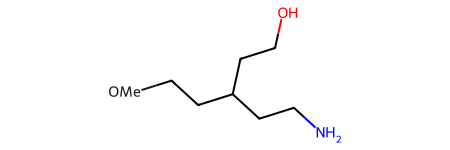

In [38]:
mol

In [39]:
mol=rw_combined
padding=20
scaling_factor=30
writeSVG=True

AllChem.Compute2DCoords(mol)
# 获取分子的2D坐标
conf = mol.GetConformer()
xs = [conf.GetAtomPosition(i).x for i in range(mol.GetNumAtoms())]
ys = [conf.GetAtomPosition(i).y for i in range(mol.GetNumAtoms())]

# 计算边界框
min_x, max_x = min(xs), max(xs)
min_y, max_y = min(ys), max(ys)

# 计算分子的宽度和高度
mol_width = max_x - min_x
mol_height = max_y - min_y

# 设置SVG图像的宽度和高度，添加填充
svg_width = int(mol_width * scaling_factor) + 2 * padding
svg_height = int(mol_height * scaling_factor) + 2 * padding

dm = Draw.PrepareMolForDrawing(mol)
d2d = Draw.MolDraw2DSVG(svg_width, svg_height)
d2d.drawOptions().useBWAtomPalette()  # 使用黑白原子调色板, 高亮需要
d2d.DrawMolecule(dm)
d2d.AddMoleculeMetadata(dm)
d2d.FinishDrawing()
# 获取SVG字符串
svg = d2d.GetDrawingText()
doc = minidom.parseString(svg)
if writeSVG:
    with open(f"{writeSVG}_view.svg", "w") as file:
        file.write(svg)
doc = minidom.parseString(svg)
# return svg,doc, mol,svg_width, svg_height    

NameError: name 'rw_combined' is not defined

In [69]:
atoms_A,len(rw_combined.GetAtoms())

(10, 11)

In [115]:
cyano.GetAtoms()[0].SetProp("atomLabel", "CF3")

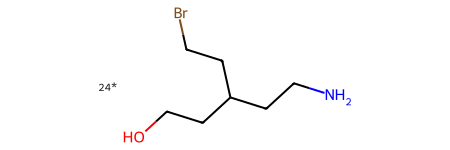

In [ ]:
combined_mol

In [35]:
import PIL

In [27]:
# _model.training=False
_model.eval()#have to uset this
with torch.no_grad():
    print(_model.training)
    outputs = _model(tensor)

ori_size=torch.Tensor([w,h]).long().unsqueeze(0)
# result_ = postprocessor(outputs, ori_size)
result_ = postprocessor2(outputs, ori_size)

# result_ = postprocessor(out_, torch.Tensor([w,h]))
score_=result_[0]['scores']
boxe_=result_[0]['boxes']
label_=result_[0]['labels']
selected_indices =score_ > 0.5
# selected_indices =score_ > score_.mean()

# 统计 True 的数量
true_count = selected_indices.sum().item()
print(f"selected_indices 中 True 的数量: {true_count}")

output={
    'labels': label_[selected_indices],
    'boxes': boxe_[selected_indices],
    'scores': score_[selected_indices]
}

filtered_output_dict={image_path: output
}


x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
center_coords = torch.stack((x_center, y_center), dim=1)
output = {'bbox':         output["boxes"].to("cpu").numpy(),
            'bbox_centers': center_coords.to("cpu").numpy(),
            'scores':       output["scores"].to("cpu").numpy(),
            'pred_classes': output["labels"].to("cpu").numpy()}

False
selected_indices 中 True 的数量: 17


In [28]:
#visual checking
predict_boxes = output['bbox']
predict_classes = output['pred_classes']
predict_scores = output['scores']

img_ori = Image.open(image_path).convert('RGB')
w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
print(w_ori, h_ori, "orignianl vs 1000,1000")
# 计算缩放比例
scale_x = 1000 / w_ori
scale_y = 1000 / h_ori
img_ori_1k = img_ori.resize((1000,1000))
img = Image.open(image_path).convert('RGB')
img = img.resize((1000,1000))
newbox = predict_boxes * [scale_x, scale_y, scale_x, scale_y]
boxed_img = draw_objs(img,
                        newbox,
                        predict_classes,
                        predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)

atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])

smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit



570 647 orignianl vs 1000,1000


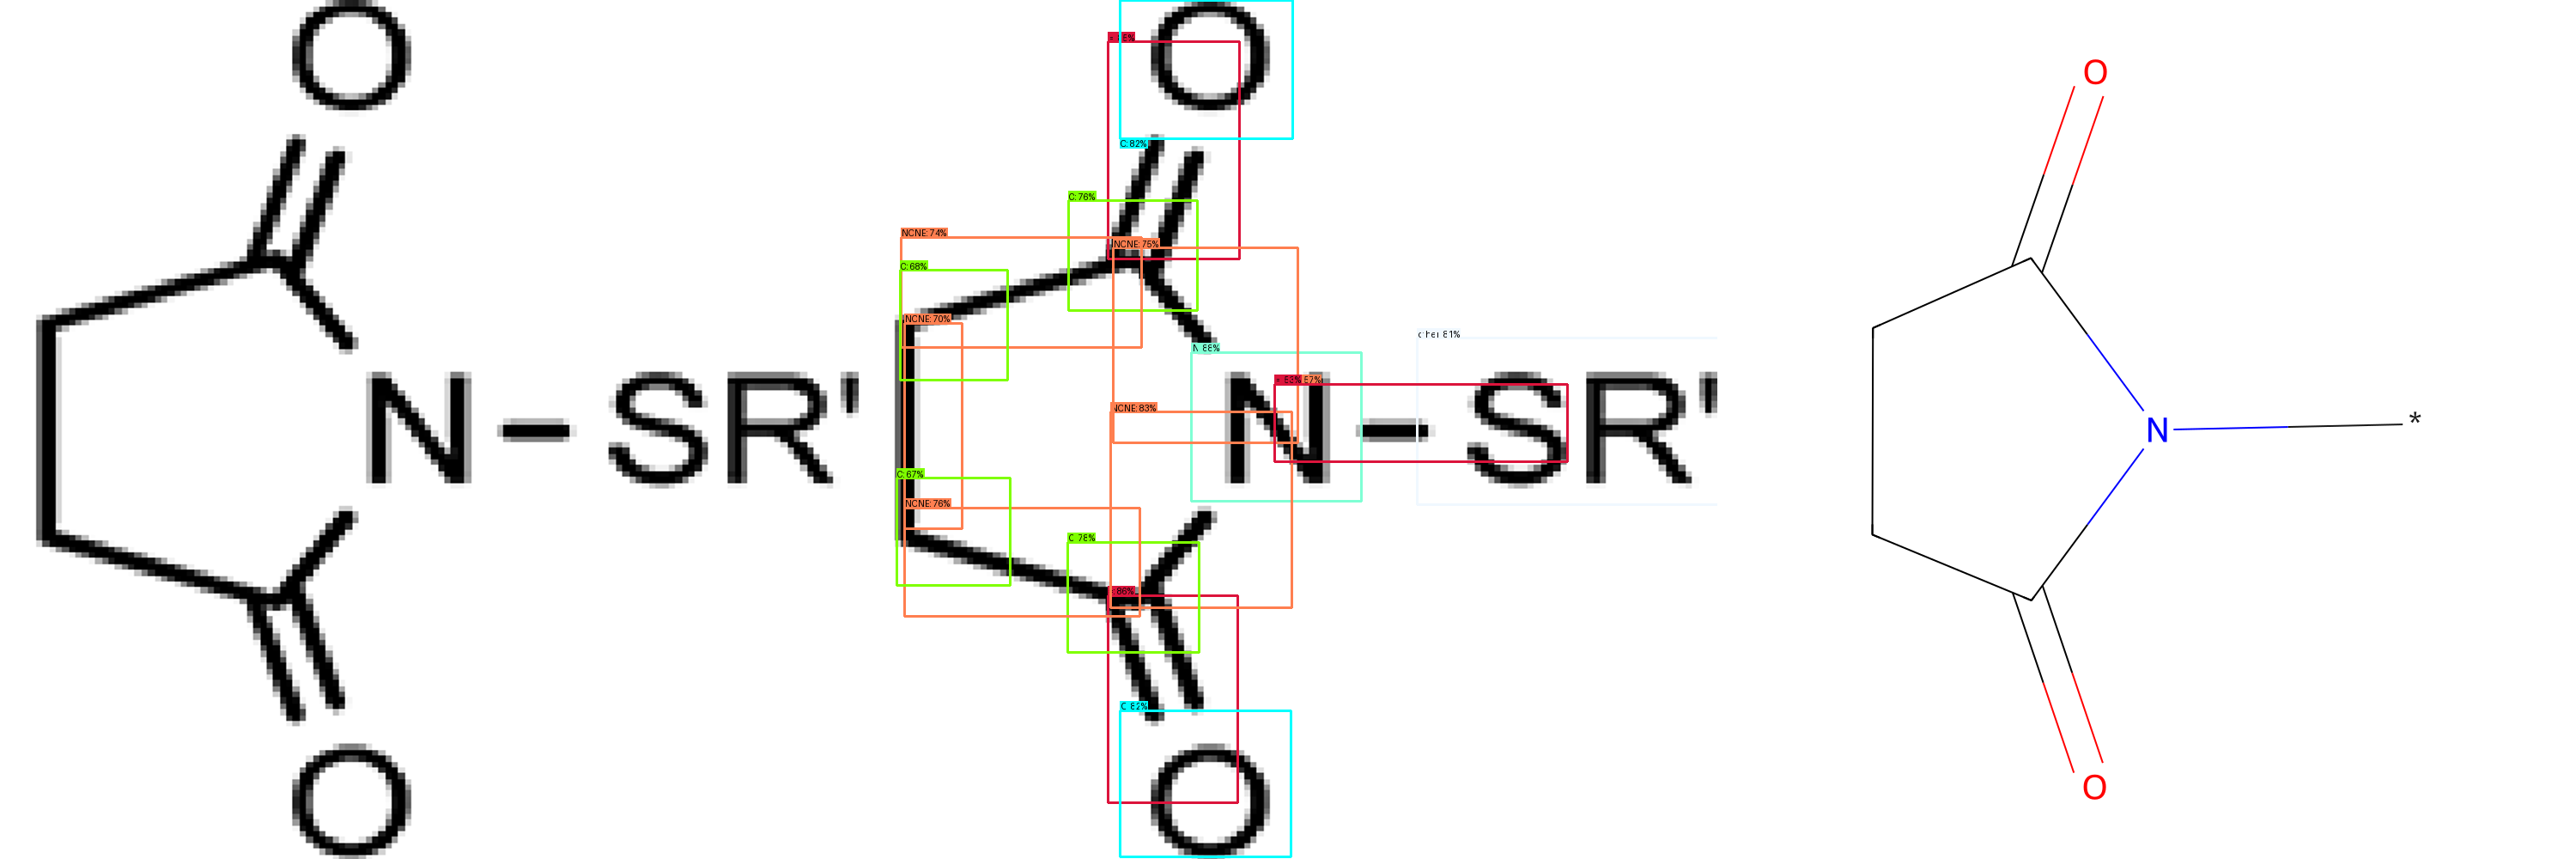

In [30]:
#check & saving
visual_check=True
other2ppsocr=False
opts = Draw.MolDrawOptions()
opts.addAtomIndices = False
opts.addStereoAnnotation = False

# TODO #[3H] 2H prpared box for training are too smalled, need adjust
if visual_check:
    img_ori = Image.open(image_path).convert('RGB')
    img_ori_1k = img_ori.resize((1000,1000))
    if other2ppsocr:
        img_rebuit = Draw.MolToImage(final_mol, options=opts,size=(1000, 1000))
    else:
        img_rebuit = Draw.MolToImage(mol_rebuit, options=opts,size=(1000, 1000))
    combined_img = Image.new('RGB', (img_ori_1k.width + boxed_img.width + img_rebuit.width, img_ori_1k.height))
    combined_img.paste(img_ori_1k, (0, 0))
    combined_img.paste(boxed_img, (img_ori_1k.width, 0))
    combined_img.paste(img_rebuit, (img_ori_1k.width + boxed_img.width, 0))
combined_img
# plot_img.save('/home/jovyan/rt-detr/src/solver/image1.png')


In [35]:
from paddleocr import PaddleOCR
ocr = PaddleOCR(use_angle_cls=True,use_gpu =False,
    rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer',
    lang="en")  # need to run only once to download and load model into memory

#* recong used

/home/jovyan/bo2/miniconda/envs/ocr/lib/python3.9/site-packages/paddle/utils/cpp_extension/extension_utils.py:686: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


[2025/01/13 05:42:25] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/jovyan/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_le

In [44]:
other_care=[]
crops=[]
for i, idx in enumerate(predict_classes): 
    if idx==0:
        print(idx_to_labels[idx],predict_scores[i],predict_boxes[i])
        img2cut = Image.open(image_path).convert('RGB')
        cropped_img = img2cut.crop(predict_boxes[i])
        crops.append(cropped_img)
        
# idx_to_labels

other 0.81146705 [370.83536 254.86217 572.0367  379.86346]


In [46]:
cropped_img.size

(201, 125)

In [47]:
image_np = np.array(cropped_img)
result = ocr.ocr(image_np, det=False)
s_, score_ =result[0][0]

In [48]:
s_, score_

('SR', 0.9089964628219604)

In [ ]:
rd_ml=Chem.MolFromSmiles("O=C(N1S[R'])CCC1=O")
smiles, ddf.SMILES[idrow]